# Debugging Execution Flow: Practice Exercise

Apply LangGraph debugging techniques to a content moderation workflow. You will use streaming to observe state evolution and add an interrupt to pause and inspect a critical decision point.

**What you'll implement:**
- Use streaming to observe state changes across nodes
- Add an interrupt to a classification node for inspection

**Estimated time:** 10-15 minutes

In [1]:
!pip install langchain-core langchain-openai langgraph python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.0 MB/s eta 0:00:00


In [3]:
import os
from functools import lru_cache

DEFAULT_REQUIRED_KEYS = ("OPENAI_API_KEY", "TAVILY_API_KEY")

@lru_cache(maxsize=1)
def configure_environment(required_keys=None):
    """
    Factory function to configure environment variables.
    Executes once and caches results.
    """
    if required_keys is None:
        required_keys = ("OPENAI_API_KEY", "TAVILY_API_KEY")

    IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ

    if IN_COLAB:
        from google.colab import userdata
        print("Configuring for Google Colab environment...")
        for key in required_keys:
            try:
                os.environ[key] = userdata.get(key)
            except Exception:
                print(f"Warning: Could not find {key} in Colab secrets.")
    else:
        from dotenv import load_dotenv
        print("Configuring for local environment...")
        load_dotenv()

    # Validation
    for key in required_keys:
        if not os.getenv(key):
            raise ValueError(f"Missing required environment variable: {key}")

    return True

In [4]:
# Initialize environment using the factory function
import os
try:
    configure_environment(("OPENAI_API_KEY",))
    print("Setup complete!")
except Exception as e:
    print(f"Setup failed: {e}")

Configuring for Google Colab environment...
Setup complete!


## Setup

Run this cell to set up all dependencies and the base workflow you will debug.

In [5]:
# Setup - run this cell first



from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
import json


assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found in environment"

# State schema for content moderation workflow
class ModerationState(TypedDict):
    """State schema for content moderation workflow."""
    content: str           # The content to moderate
    category: str          # Classification result: "safe", "review", or "block"
    confidence: float      # Confidence score 0.0-1.0
    action_taken: str      # What action was performed
    final_output: str      # Final result message

# Classification schema
class ContentClassification(BaseModel):
    """Schema for content classification results."""
    category: Literal["safe", "review", "block"] = Field(
        description="Classification: 'safe' for appropriate content, 'review' for borderline content needing human review, 'block' for clearly inappropriate content"
    )
    confidence: float = Field(
        description="Confidence score between 0.0 and 1.0",
        ge=0.0,
        le=1.0
    )
    reasoning: str = Field(
        description="Brief explanation of the classification decision"
    )

# Initialize LLM and classifier
llm = ChatOpenAI(model="gpt-4o", temperature=0)
content_classifier = llm.with_structured_output(ContentClassification)

print("Setup complete!")

Setup complete!


## Provided Workflow

Below is a content moderation workflow with three paths:
- **safe**: Content is approved and published
- **review**: Content is flagged for human review
- **block**: Content is rejected

The classification node and processing nodes are provided. Your task is to debug this workflow using the techniques from the lesson.

In [6]:
# Provided: Classification node (you will modify this later)
def classify_content_node(state: ModerationState) -> ModerationState:
    """Classifies content into safe, review, or block categories."""
    content = state["content"]

    system_prompt = """You are a content moderation classifier.

Classify the content into one of three categories:
- SAFE: Appropriate content that can be published immediately
- REVIEW: Borderline content that needs human review (ambiguous, potentially sensitive)
- BLOCK: Clearly inappropriate content that should be rejected

Provide your classification with confidence score and reasoning.
"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Content to classify: {content}"}
    ]

    result = content_classifier.invoke(messages)

    print(f"Classification: {result.category}")
    print(f"Confidence: {result.confidence}")
    print(f"Reasoning: {result.reasoning}")

    return {
        "category": result.category,
        "confidence": result.confidence
    }

# Provided: Processing nodes
def approve_content_node(state: ModerationState) -> ModerationState:
    """Approves safe content for publication."""
    print("Approving content for publication...")
    return {
        "action_taken": "approved",
        "final_output": f"Content approved and published: '{state['content'][:50]}...'"
    }

def flag_for_review_node(state: ModerationState) -> ModerationState:
    """Flags content for human review."""
    print("Flagging content for human review...")
    return {
        "action_taken": "flagged_for_review",
        "final_output": f"Content flagged for human review (confidence: {state['confidence']})"
    }

def block_content_node(state: ModerationState) -> ModerationState:
    """Blocks inappropriate content."""
    print("Blocking inappropriate content...")
    return {
        "action_taken": "blocked",
        "final_output": "Content blocked due to policy violation."
    }

# Provided: Router function
def route_by_category(state: ModerationState) -> Literal["approve", "review", "block"]:
    """Routes to appropriate node based on classification."""
    category = state["category"]
    print(f"Routing to: {category}")

    if category == "safe":
        return "approve"
    elif category == "review":
        return "review"
    else:
        return "block"

print("Workflow nodes defined!")

Workflow nodes defined!


In [7]:
# Provided: Build and compile the basic workflow
workflow = StateGraph(ModerationState)

workflow.add_node("classify", classify_content_node)
workflow.add_node("approve", approve_content_node)
workflow.add_node("review", flag_for_review_node)
workflow.add_node("block", block_content_node)

workflow.add_edge(START, "classify")
workflow.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "approve": "approve",
        "review": "review",
        "block": "block"
    }
)
workflow.add_edge("approve", END)
workflow.add_edge("review", END)
workflow.add_edge("block", END)

moderation_app = workflow.compile()

print("Workflow compiled!")

Workflow compiled!


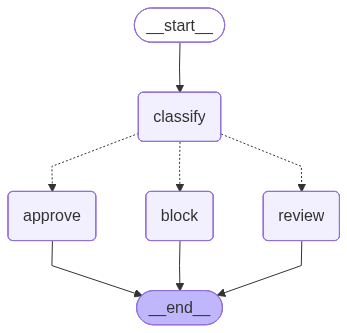

In [9]:
from IPython.display import Image, display

# display the graph
mermaid_graph = moderation_app.get_graph().draw_mermaid_png()
display(Image(mermaid_graph))

## Task 1: Debug with Streaming

Use the `updates` streaming mode to observe what each node contributes to the state. This will help you see exactly which fields each node modifies.

Your function should:
- Stream the workflow execution using `updates` mode
- Print the node name and its state updates for each chunk
- Return a list of tuples containing (node_name, updates_dict) for each update

In [10]:
def stream_with_updates(app, initial_state: dict) -> list:
    """
    Stream workflow execution using 'updates' mode and capture node contributions.

    Args:
        app: The compiled LangGraph application
        initial_state: The initial state dictionary to start execution

    Returns:
        A list of tuples: [(node_name, updates_dict), ...]
        where node_name is the name of the node that executed,
        and updates_dict contains the state fields that node modified.
    """
    # TODO: Implement streaming with 'updates' mode
    # 1. Create an empty list to collect results
    # 2. Use app.stream() with stream_mode="updates"
    # 3. For each chunk, extract the node name (it's the key in the chunk dict)
    # 4. Print the node name and its updates
    # 5. Append (node_name, updates_dict) to your results list
    # 6. Return the collected results
    results = []
    for chunk in app.stream(initial_state, stream_mode="updates"):
        node_name = list(chunk.keys())[0]
        updates_dict = chunk[node_name]
        print(f"Node: {node_name}, Updates: {updates_dict}")
        results.append((node_name, updates_dict))
    return results


## Test Task 1

Run your streaming function with a test content sample.

In [11]:
# Test your streaming implementation
test_content = "Check out this amazing new recipe for chocolate chip cookies!"

initial_state = {
    "content": test_content,
    "category": "",
    "confidence": 0.0,
    "action_taken": "",
    "final_output": ""
}

print(f"Content: {test_content}")
print("=" * 60)

updates = stream_with_updates(moderation_app, initial_state)

print("\n" + "=" * 60)
print(f"Total updates captured: {len(updates)}")

Content: Check out this amazing new recipe for chocolate chip cookies!
Classification: safe
Confidence: 0.95
Reasoning: The content is a simple and positive statement about a recipe for chocolate chip cookies, which is a common and non-controversial topic. There are no indications of sensitive or inappropriate material.
Routing to: safe
Node: classify, Updates: {'category': 'safe', 'confidence': 0.95}
Approving content for publication...
Node: approve, Updates: {'action_taken': 'approved', 'final_output': "Content approved and published: 'Check out this amazing new recipe for chocolate ch...'"}

Total updates captured: 2


## Task 2: Add an Interrupt for Inspection

Create a modified version of the classification node that includes an interrupt. This allows you to pause after classification and inspect the decision before routing continues.

Your interrupt payload should include:
- A message indicating classification is complete
- The detected category
- The confidence score
- The original content being moderated

In [12]:
def classify_content_with_interrupt(state: ModerationState) -> ModerationState:
    """
    Classifies content and pauses with an interrupt for inspection.

    Args:
        state: The current moderation state containing 'content' field

    Returns:
        Updated state with 'category' and 'confidence' fields set.

    Interrupt Payload:
        The interrupt should contain a dict with:
        - "message": A string indicating classification is complete
        - "category": The classification result
        - "confidence": The confidence score
        - "content": The original content being moderated
    """
    content = state["content"]

    system_prompt = """You are a content moderation classifier.

Classify the content into one of three categories:
- SAFE: Appropriate content that can be published immediately
- REVIEW: Borderline content that needs human review (ambiguous, potentially sensitive)
- BLOCK: Clearly inappropriate content that should be rejected

Provide your classification with confidence score and reasoning.
"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Content to classify: {content}"}
    ]

    result = content_classifier.invoke(messages)

    print(f"Classification: {result.category}")
    print(f"Confidence: {result.confidence}")
    print(f"Reasoning: {result.reasoning}")

    # TODO: Add an interrupt here with the specified payload
    # Use the interrupt() function with a dict containing:
    # - "message", "category", "confidence", "content"

    interrupt_payload = {
        "message": "Classification complete",
        "category": result.category,
        "confidence": result.confidence,
    }
    interrupt(interrupt_payload)
    return {
        "category": result.category,
        "confidence": result.confidence
    }

## Build Workflow with Interrupt

Run this cell to rebuild the workflow using your interrupt-enabled classification node.

In [14]:
# Build workflow with interrupt-enabled node
workflow_debug = StateGraph(ModerationState)

workflow_debug.add_node("classify", classify_content_with_interrupt)
workflow_debug.add_node("approve", approve_content_node)
workflow_debug.add_node("review", flag_for_review_node)
workflow_debug.add_node("block", block_content_node)

workflow_debug.add_edge(START, "classify")
workflow_debug.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "approve": "approve",
        "review": "review",
        "block": "block"
    }
)
workflow_debug.add_edge("approve", END)
workflow_debug.add_edge("review", END)
workflow_debug.add_edge("block", END)

# Compile with checkpointer for interrupt support
checkpointer = MemorySaver()
moderation_app_debug = workflow_debug.compile(checkpointer=checkpointer)

print("Debug workflow compiled with checkpointer!")

Debug workflow compiled with checkpointer!


## Test Task 2

Test your interrupt implementation by running the workflow, inspecting the paused state, and resuming execution.

In [15]:
# Test interrupt: Phase 1 - Execute until interrupt
test_content_interrupt = "This product changed my life! Best purchase ever!"

config = {"configurable": {"thread_id": "moderation-debug-1"}}

initial_state = {
    "content": test_content_interrupt,
    "category": "",
    "confidence": 0.0,
    "action_taken": "",
    "final_output": ""
}

print(f"Content: {test_content_interrupt}")
print("=" * 60)
print("\nPhase 1: Running until interrupt...")
print("=" * 60)

result = moderation_app_debug.invoke(initial_state, config)

print("\nExecution paused at interrupt!")

Content: This product changed my life! Best purchase ever!

Phase 1: Running until interrupt...
Classification: safe
Confidence: 0.95
Reasoning: The content is a positive product review expressing satisfaction and does not contain any inappropriate or sensitive material. It is suitable for publication without further review.

Execution paused at interrupt!


In [16]:
# Test interrupt: Phase 2 - Inspect state at interrupt
print("INSPECTING STATE AT INTERRUPT")
print("=" * 60)

print(f"\nContent: {result['content']}")
print(f"Category: {result['category'] or 'Not yet set'}")
print(f"Confidence: {result['confidence']}")
print(f"Action Taken: {result['action_taken'] or 'Not yet set'}")

if '__interrupt__' in result:
    print("\nInterrupt Payload:")
    for interrupt_info in result['__interrupt__']:
        payload = interrupt_info.value
        for key, value in payload.items():
            print(f"  {key}: {value}")

INSPECTING STATE AT INTERRUPT

Content: This product changed my life! Best purchase ever!
Category: Not yet set
Confidence: 0.0
Action Taken: Not yet set

Interrupt Payload:
  message: Classification complete
  category: safe
  confidence: 0.95


In [17]:
# Test interrupt: Phase 3 - Resume execution
print("Phase 3: Resuming execution...")
print("=" * 60)

final_result = moderation_app_debug.invoke(Command(resume=True), config)

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)
print(f"Category: {final_result['category']}")
print(f"Action: {final_result['action_taken']}")
print(f"Output: {final_result['final_output']}")

Phase 3: Resuming execution...
Classification: safe
Confidence: 0.95
Reasoning: The content is a positive product review expressing personal satisfaction. It contains no inappropriate language or sensitive topics, making it suitable for publication without further review.
Routing to: safe
Approving content for publication...

FINAL RESULT
Category: safe
Action: approved
Output: Content approved and published: 'This product changed my life! Best purchase ever!...'
